# Group 16 — YOLOv8n Baseline Training
**Dataset:** D-Fire | **Epochs:** 20 | **Model:** YOLOv8n fine-tuned from COCO weights

In [1]:
!pip install ultralytics --quiet
import ultralytics
ultralytics.checks()

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)


In [2]:
import yaml
from pathlib import Path

DFIRE_ROOT = Path('/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data')

print('=== D-Fire Verification ===')
for split in ['train', 'val', 'test']:
    n = len(list((DFIRE_ROOT / split / 'images').glob('*')))
    print(f'  {split:6s}: {n:6d} images')

with open(DFIRE_ROOT.parent / 'data.yaml') as f:
    orig = yaml.safe_load(f)
print(f'\nClasses: {orig["names"]}')

YAML_PATH = Path('/kaggle/working/dfire.yaml')
with open(YAML_PATH, 'w') as f:
    yaml.dump({
        'path':  str(DFIRE_ROOT),
        'train': 'train/images',
        'val':   'val/images',
        'test':  'test/images',
        'nc':    orig['nc'],
        'names': orig['names']
    }, f, default_flow_style=False)

print(f'data.yaml ready.')

=== D-Fire Verification ===
  train :  14122 images
  val   :   3099 images
  test  :   4306 images

Classes: ['smoke', 'fire']
data.yaml ready.


In [3]:
import torch
from ultralytics import YOLO

print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

model = YOLO('yolov8n.pt')

model.train(
    data=str(YAML_PATH),
    epochs=20,
    imgsz=640,
    batch=16,
    device=0 if torch.cuda.is_available() else 'cpu',
    workers=2,
    seed=42,
    patience=10,
    save=True,
    project='/kaggle/working/runs',
    name='yolov8n_dfire',
    exist_ok=True,
)

GPU: Tesla T4
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dfire.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_dfire, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7de843c10e30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [4]:
import time, glob
from ultralytics import YOLO

WEIGHTS = '/kaggle/working/runs/yolov8n_dfire/weights/best.pt'
trained = YOLO(WEIGHTS)

metrics = trained.val(
    data=str(YAML_PATH),
    split='test',
    imgsz=640,
    batch=16,
    verbose=False,
)

# FPS on 100 test images
test_imgs = glob.glob(str(DFIRE_ROOT / 'test/images/*'))[:100]
t0 = time.time()
for p in test_imgs:
    trained.predict(p, imgsz=640, verbose=False)
fps = len(test_imgs) / (time.time() - t0)

p  = metrics.box.mp
r  = metrics.box.mr
f1 = 2 * p * r / (p + r + 1e-9)

print('\n' + '='*50)
print('   YOLOv8n RESULTS  —  D-Fire  —  20 Epochs')
print('='*50)
print(f'  mAP50        : {metrics.box.map50:.4f}')
print(f'  mAP50-95     : {metrics.box.map:.4f}')
print(f'  Precision    : {p:.4f}')
print(f'  Recall       : {r:.4f}')
print(f'  F1 Score     : {f1:.4f}')
print(f'  FPS (sim.)   : {fps:.1f}')
print('='*50)
print('\n  Per-Class AP50:')
for i, name in enumerate(orig['names']):
    try:
        print(f'    {name:10s}: {metrics.box.ap50[i]:.4f}')
    except:
        print(f'    {name:10s}: N/A')

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.4 ms, read: 13.6±8.4 MB/s, size: 232.3 KB)
val: Scanning /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/labels... 4295 images, 2005 backgrounds, 15 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 160.4it/s 26.8s
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0297]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0156]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB11243.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/sayedgamal99/sm

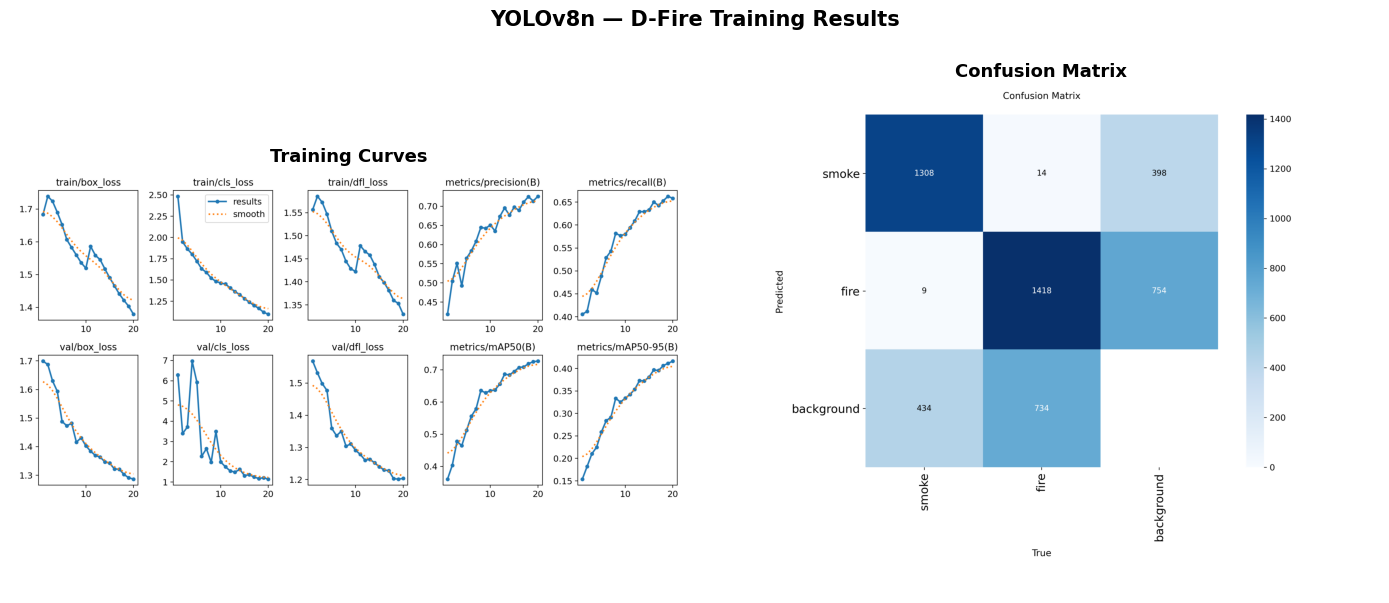

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

RUN_DIR = Path('/kaggle/working/runs/yolov8n_dfire')

plots = {
    'Training Curves':  RUN_DIR / 'results.png',
    'Confusion Matrix': RUN_DIR / 'confusion_matrix.png',
    'PR Curve':         RUN_DIR / 'PR_curve.png',
    'F1 Curve':         RUN_DIR / 'F1_curve.png',
}

available = {k: v for k, v in plots.items() if v.exists()}
n = len(available)

fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
if n == 1:
    axes = [axes]

for ax, (title, path) in zip(axes, available.items()):
    ax.imshow(mpimg.imread(str(path)))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('YOLOv8n — D-Fire Training Results', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

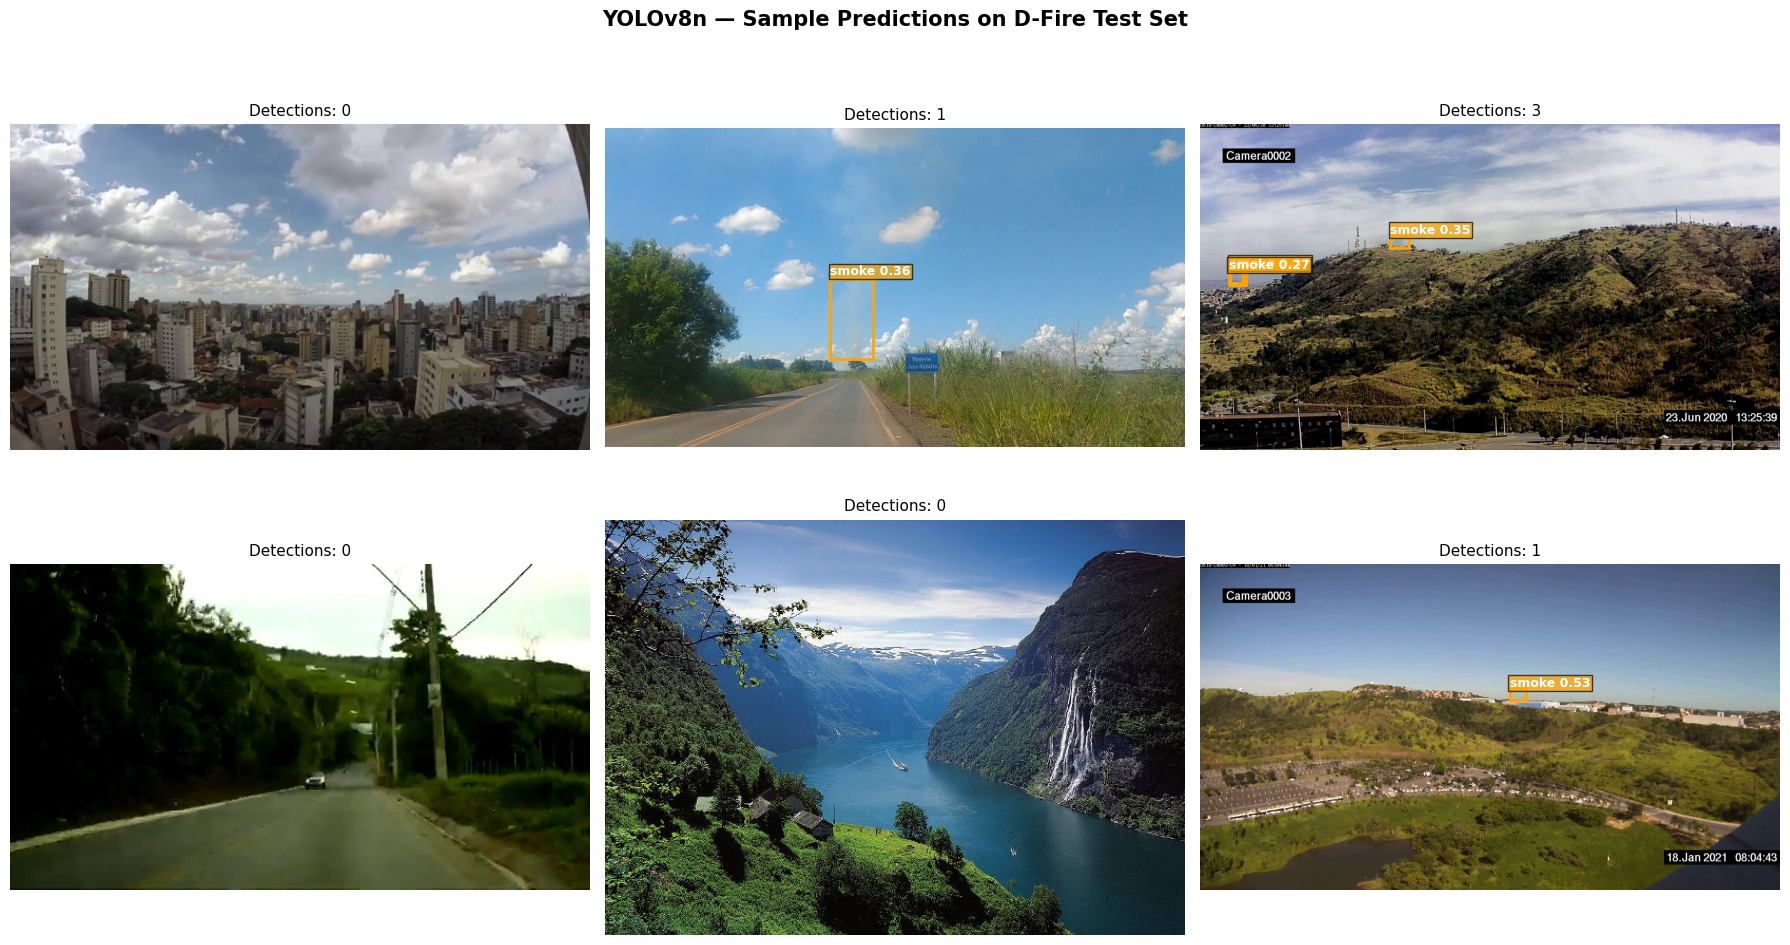

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random, glob

random.seed(42)
sample_imgs = random.sample(glob.glob(str(DFIRE_ROOT / 'test/images/*')), 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_imgs):
    result = trained.predict(img_path, imgsz=640, conf=0.25, verbose=False)[0]
    img    = Image.open(img_path).convert('RGB')
    ax.imshow(img)

    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls   = int(box.cls)
        conf  = float(box.conf)
        label = orig['names'][cls]
        color = 'red' if label == 'fire' else 'orange'

        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        ))
        ax.text(x1, y1 - 5, f'{label} {conf:.2f}',
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.7, pad=1))

    ax.set_title(f'Detections: {len(result.boxes)}', fontsize=11)
    ax.axis('off')

plt.suptitle('YOLOv8n — Sample Predictions on D-Fire Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()